In [26]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from time import time
from tqdm.auto import tqdm

from quspin.basis import spin_basis_1d
from quspin.operators import hamiltonian

import geodesiq as gq

In [2]:
def ising_model(lam, L, hx, hz):
    """
    Constructs the Ising ControlModel with transverse (hx) and longitudinal (hz) fields.
    """
    zz_list = [[lam, i, i + 1] for i in range(L - 1)]
    z_list = [[lam * hz, i] for i in range(L)]
    x_list = [[(1 - lam) * hx, i] for i in range(L)]

    static = [["zz", zz_list], ["z", z_list], ["x", x_list]]

    basis = spin_basis_1d(L, pblock=1)
    H = hamiltonian(static, [], basis=basis, dtype=np.float64, check_symm=False, check_herm=False)

    return H.toarray()

def count_time(model, accuracy: int):
    model.solve_problem(pulse_accuracy=int(100))

    t0 = time()
    model.solve_problem(pulse_accuracy=int(accuracy))
    tf = time()
    return tf - t0

In [3]:
alpha, beta = 2, 2
initial_state = 0

hx, hz = 1, .8
lam0, lamf = 0, 1

In [24]:
Ls[0]

np.int64(2)

In [25]:
Ls = np.arange(2, 10, dtype=int)
accuracies = [1e2, 1e3, 1e4, 1e5]
n_shots = 10

results = []
for L in tqdm(Ls, desc='Iterating in L'):

    ising = gq.ControlModel(ising_model)
    ising.set_parameters(L=int(L), hx=hx, hz=hz)
    ising.set_control(control_name='lam', pulse_initial=lam0, pulse_final=lamf, initial_state=initial_state, alpha=alpha,
                      beta=beta, num_steps=2 ** 4 + 1)
    
    partial_resul = []
    for accuracy in tqdm(accuracies, desc='Iterating in accuracy', leave=False):
        temp = 0
        for _ in range(n_shots):
            temp += count_time(ising, accuracy)

        partial_resul.append(temp / n_shots)
    results.append(partial_resul)
results = np.array(results)

Iterating in L:   0%|          | 0/8 [00:00<?, ?it/s]

Iterating in accuracy:   0%|          | 0/4 [00:00<?, ?it/s]

Iterating in accuracy:   0%|          | 0/4 [00:00<?, ?it/s]

Iterating in accuracy:   0%|          | 0/4 [00:00<?, ?it/s]

Iterating in accuracy:   0%|          | 0/4 [00:00<?, ?it/s]

Iterating in accuracy:   0%|          | 0/4 [00:00<?, ?it/s]

Iterating in accuracy:   0%|          | 0/4 [00:00<?, ?it/s]

Iterating in accuracy:   0%|          | 0/4 [00:00<?, ?it/s]

Iterating in accuracy:   0%|          | 0/4 [00:00<?, ?it/s]

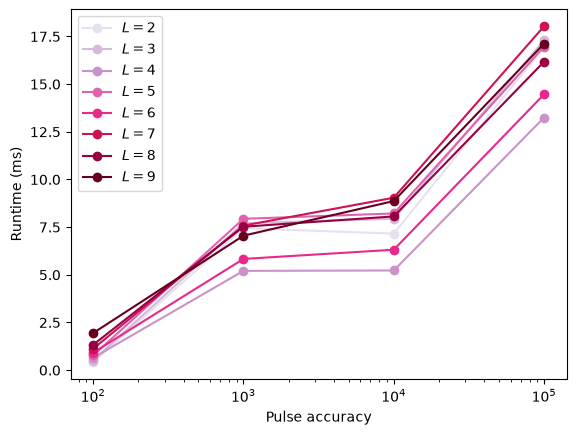

In [31]:
fig, ax = plt.subplots()

cmap = plt.colormaps["PuRd"]
norm = Normalize(vmin=1, vmax=max(Ls))
colors = [cmap(norm(value)) for value in Ls]

for i in range(len(Ls)):
    ax.plot(accuracies, results[i] * 1e3, label=rf'$L = {Ls[i]}$', marker='o', color=colors[i])

ax.set_xlabel('Pulse accuracy')
ax.set_ylabel('Runtime (ms)')
ax.set_xscale('log')
ax.legend();